<a href="https://colab.research.google.com/github/alfarisauliarahman/Alfaris-Aulia-Rahman_2411533006_ML2526/blob/main/Praktikum2/BernoulliNaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import library yang diperlukan dan generate dummy dataset.


  Pada praktikum ini kita akan menggunakan data dummy yaitu golf dataset untuk melatih model Bernoulli Naive Bayes yang akan digunakan untuk memprediksi apakah seseorang akan bermain golf berdasarkan kondisi cuaca.

In [1]:
# Import neede libraries
import pandas as pd
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Load the Dataset
dataset_dict = {
    'Outlook': ['sunny', 'sunny', 'overcast', 'rainy', 'rainy', 'rainy', 'overcast', 'sunny', 'sunny', 'rainy', 'sunny', 'overcast', 'overcast', 'rainy', 'sunny', 'overcast', 'rainy', 'sunny', 'sunny', 'rainy', 'overcast', 'rainy', 'sunny', 'overcast', 'sunny', 'overcast', 'rainy', 'overcast'],
    'Temperature': [85.0, 80.0, 83.0, 70.0, 68.0, 65.0, 64.0, 72.0, 69.0, 75.0, 75.0, 72.0, 81.0, 71.0, 81.0, 74.0, 76.0, 78.0, 82.0, 67.0, 85.0, 73.0, 88.0, 77.0, 79.0, 80.0, 66.0, 84.0],
    'Humidity': [85.0, 90.0, 78.0, 96.0, 80.0, 70.0, 65.0, 95.0, 70.0, 80.0, 70.0, 90.0, 75.0, 80.0, 88.0, 92.0, 85.0, 75.0, 92.0, 90.0, 85.0, 88.0, 65.0, 70.0, 60.0, 95.0, 70.0, 78.0],
    'Wind': [False, True, False, False, False, True, True, False, False, False, True, True, False, True, True, False, False, True, False, True, True, False, True, False, False, True, False, False],
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes']
}
df = pd.DataFrame(dataset_dict)

df.head()

,Outlook,Temperature,Humidity,Wind,Play
0,sunny,85.0,85.0,False,No
1,sunny,80.0,90.0,True,No
2,overcast,83.0,78.0,False,Yes
3,rainy,70.0,96.0,False,Yes
4,rainy,68.0,80.0,False,Yes


2. Tampilkan histogram untuk class/target dari data yang dimiliki

<Axes: >

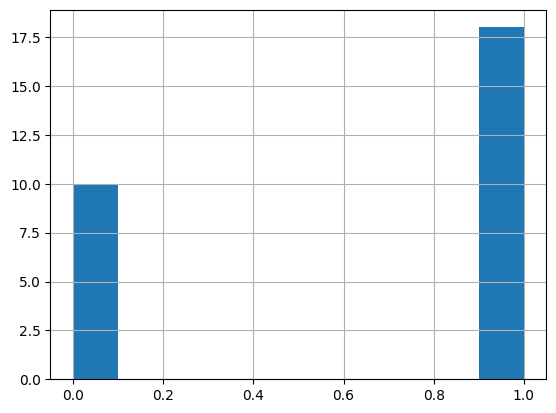

In [3]:
df["Play"].hist()

3. Data Prepocessing

Karena semua fitur harus dalam format 0 dan 1, maka kita perlu mengkonversi nilai fitur yang ada saat
ini ke dalam format biner.

* Pertama kita akan mengkonversi fitur 'Outlook' dengan menggunakan algoritma One-Hot
Encoding (OHE) yang akan mengubah nilai kategori menjadi bentuk numerik biner. Kemudian,
nilai dari fitur Wind dan kelas/label 'Play' juga akan dikonversi dari boolean ke bentuk biner.   

In [2]:
# ONE-HOT ENCOCE 'Outlook' COLUMN
df = pd.get_dummies(df, columns=['Outlook'], prefix='', prefix_sep='', dtype=int)

# CONVERT 'Windy' (bool) and 'Play' (binary) COLUMNS TO BINARY INDICATORS
df['Wind'] = df['Wind'].astype(int)
df['Play'] = (df['Play'] == 'Yes').astype(int)

df.head()

,Temperature,Humidity,Wind,Play,overcast,rainy,sunny
0,85.0,85.0,0,0,0,0,1
1,80.0,90.0,1,0,0,0,1
2,83.0,78.0,0,1,1,0,0
3,70.0,96.0,0,1,0,1,0
4,68.0,80.0,0,1,0,1,0


*   Selanjutnya, karena masih ada fitur yang belum dalam format biner yaitunya Temperatur dan Humidity maka kita juga akan mengkonversi fitur tersebut ke dalam bentuk biner. Caranya adalah dengan membagi nilai Temperatur menjadi ≤ 80 dan > 80. Untuk nilai temperatur ≤ 80 kita artikan Warm, sedangkan > 80 adalah Hot. Kemudian kita gunakan One-hot encode untuk mengkonversi nilai/kategori tersebut menjadi bentuk biner, 1 mewakili temperatur Hot dan 0 mewakili temperatur Warm
*   Hal yang sama juga dilakukan untuk fitur Humidity, nilai humidity dipisahkan menjadi ≤ 75 dan > 75. Nilai ≤ 75 dilabeli dengan Dry dan > 75 dilabeli dengan Humid. Saat dikonversi, nilai 1 akan mewakili Humid dan 0 mewakili Dry

In [4]:
# One-hot encode the categorized columns and drop them after
# Define categories for 'Temperature' and 'Humidity' for dataframe
df['Temperature'] = pd.cut(df['Temperature'], bins=[0, 80, 100], labels=['Warm', 'Hot'])
df['Humidity'] = pd.cut(df['Humidity'], bins=[0, 75, 100], labels=['Dry', 'Humid'])

# One-hot encode the categorized columns
one_hot_columns = pd.get_dummies(df[['Temperature', 'Humidity']], drop_first=True, dtype=int)

# Drop the categorized columns from df
df = df.drop(['Temperature', 'Humidity'], axis=1)

# Concatenate the one-hot encoded columns with the original DataFrames
df = pd.concat([one_hot_columns, df], axis=1)

df.head()

,Temperature_Hot,Humidity_Humid,Wind,Play,overcast,rainy,sunny
0,1,1,0,0,0,0,1
1,0,1,1,0,0,0,1
2,1,1,0,1,1,0,0
3,0,1,0,1,0,1,0
4,0,1,0,1,0,1,0


4. Bagi dataset menjadi data latih dan data uji

In [5]:
# Split data into training and testing sets
X, y = df.drop(columns='Play'), df['Play']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=False)

5. Pelatihan Model Naïve Bayes

Model Bernoulli Naïve Bayes dilatih dengan memanfaat modul BernoulliNB yang diimport dari library sklearn.naive_bayes

In [7]:
# Train the model
nb_clf = BernoulliNB()
nb_clf.fit(X_train, y_train)

BernoulliNB()

6. Prediksi data uji dan evaluasi serta analisis kinerja model dengan menggunakan berbagai metrik evaluasi.

In [8]:
# Make predictions
y_pred = nb_clf.predict(X_test)

# Check accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.5555555555555556


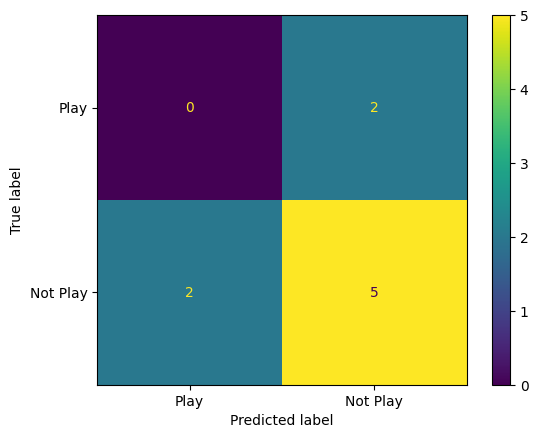

In [9]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

labels = ["Play", "Not Play"]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot();